# _Higher or Lower V2_ -- Walkthrough

This notebook will guide you through an interface for experimenting with strategies in _Higher or Lower V2_.
At the end, you can write your own strategies, and play them off against each other.

In [2]:
from pathlib import Path

for required_file in ("deck.py", "game.py", "higher_lower_rl.py"):
    assert Path(required_file).exists(), f"Missing required local module: {required_file}"


The `deck` module lets us simulate a deck of cards

In [3]:
import numpy as np
import deck

In [4]:
# We need a source of randomness
rng = np.random.RandomState()

In [5]:
# We can draw one card at random
random_card = deck.random_card(rng)

# The card is represented as an integer from 0 to 51 -- we can convert this to its suit and rank
random_card_name = deck.name_card(random_card)

print(f'Random card: {random_card_name}')

Random card: Ace of Spades (id=3)


In [6]:
# We can draw many cards without replacement by keeping track of which cards have already been drawn
random_cards = []
for _ in range(5):
    next_card = deck.draw_card(random_cards, rng)
    next_card_name = deck.name_card(next_card)
    print(f'Card drawn: {next_card_name}')

    # The integer representation allows us to easily check if a card is higher or lower than another
    if len(random_cards) > 0:
        prev_card = random_cards[-1]
        assert next_card != prev_card
        print('(Higher)' if next_card > prev_card else '(Lower)')

    random_cards.append(next_card)


Card drawn: King of Clubs (id=48)
Card drawn: King of Spades (id=51)
(Higher)
Card drawn: 9 of Diamonds (id=33)
(Lower)
Card drawn: 5 of Hearts (id=18)
(Lower)
Card drawn: 6 of Hearts (id=22)
(Higher)


The `game` module lets us simulate _Higher or Lower V2_

In [7]:
import game
from typing import List

To play the game we need a player. We can define a player by inheriting from the `game.Strategy` class

In [8]:
# This is an example of a simple strategy
class FixedProportionStrategy(game.Strategy):
    # We can optionally parameterise the strategy using a constructor
    def __init__(self, proportion: float):
        # This simple strategy will be parameterised by the proportion of our points to stake each move
        self.proportion = proportion

    # This is the method we have to implement to play the game
    def evaluate(
        self,
        # This is how many points we currently have
        my_points: int,
        # This is how many points our opponent currently has
        op_points: int,
        # This is the list of the cards we have drawn so far, in order
        prev_cards_drawn: List[int],
        # This is how many cards are left to draw
        num_remaining_draws: int,
        # We can use this to generate random numbers
        rng: np.random.RandomState,

    # The return value should be an integer between -my_points and my_points (inclusive)
    # A negative value means we choose "lower", a positive value means we choose "higher"
    # In either case, if we return x then our points will be updated to:
    #     my_points + x, if the next card is higher than the last card,
    # or: my_points - x, if the next card is lower than the last card
    ) -> int:

        # We can extract the last card drawn
        last_card = prev_cards_drawn[-1]

        # Decide how much to stake. In this strategy we always stake a fixed proportion of our points
        stake = int(self.proportion * my_points)

        # We can use the value of the last card to make a decision
        last_card_is_high = (last_card > deck.NUM_CARDS / 2)

        # In this strategy, we choose "lower" if the card is high and "higher" if the card is low
        if last_card_is_high:
            # We can choose the "lower" direction by returning a negative stake (between -my_points and 0)
            return -stake
        else:
            # We can choose the "higher" direction by returning a positive stake (between 0 and my_points)
            return stake

    # Define a name for our strategy
    def __str__(self):
        return f"FixedProp({self.proportion})"


We can now construct two players, and play them against each other

In [9]:
player_1 = FixedProportionStrategy(0.2)
player_2 = FixedProportionStrategy(0.8)

In [10]:
game_result = game.play_game(player_1, player_2, rng)

# The result is 1 if the first player wins, -1 if the second player wins, and 0 if it's a draw
print(f'> game.play_game returned: {game_result}')

Starting game
First card [3 of Hearts (id=10)]
Player 1 [FixedProp(0.2)] has 100 points
Player 2 [FixedProp(0.8)] has 100 points
Player 1 [FixedProp(0.2)] stakes 20 on higher
Player 2 [FixedProp(0.8)] stakes 80 on higher
Next card [Queen of Clubs (id=44)] is higher
Player 1 [FixedProp(0.2)] has 120 points
Player 2 [FixedProp(0.8)] has 180 points
Player 1 [FixedProp(0.2)] stakes 24 on lower
Player 2 [FixedProp(0.8)] stakes 144 on lower
Next card [2 of Diamonds (id=5)] is lower
Player 1 [FixedProp(0.2)] has 144 points
Player 2 [FixedProp(0.8)] has 324 points
Player 1 [FixedProp(0.2)] stakes 28 on higher
Player 2 [FixedProp(0.8)] stakes 259 on higher
Next card [2 of Clubs (id=4)] is lower
Player 1 [FixedProp(0.2)] has 116 points
Player 2 [FixedProp(0.8)] has 65 points
Player 1 [FixedProp(0.2)] stakes 23 on higher
Player 2 [FixedProp(0.8)] stakes 52 on higher
Next card [4 of Diamonds (id=13)] is higher
Player 1 [FixedProp(0.2)] has 139 points
Player 2 [FixedProp(0.8)] has 117 points
Player

Here are some more examples of very simple strategies

In [11]:
class ZeroStrategy(game.Strategy):
    def evaluate(
        self,
        my_points: int,
        op_points: int,
        prev_cards_drawn: List[int],
        num_remaining_draws: int,
        rng: np.random.RandomState,
    ) -> int:
        # Zero is always a valid move
        return 0

    def __str__(self):
        return "Zero"

class UniformRandomStrategy(game.Strategy):
    def evaluate(
        self,
        my_points: int,
        op_points: int,
        prev_cards_drawn: List[int],
        num_remaining_draws: int,
        rng: np.random.RandomState,
    ) -> int:
        # Here we use `rng` to generate randomness
        return rng.randint(-my_points, my_points + 1)

    def __str__(self):
        return "UniformRandom"


We can play many strategies against each other

In [12]:
strategy_list: List[game.Strategy] = [
    ZeroStrategy(),
    UniformRandomStrategy(),
    *[FixedProportionStrategy((i + 1) / 10) for i in range(10)],
]

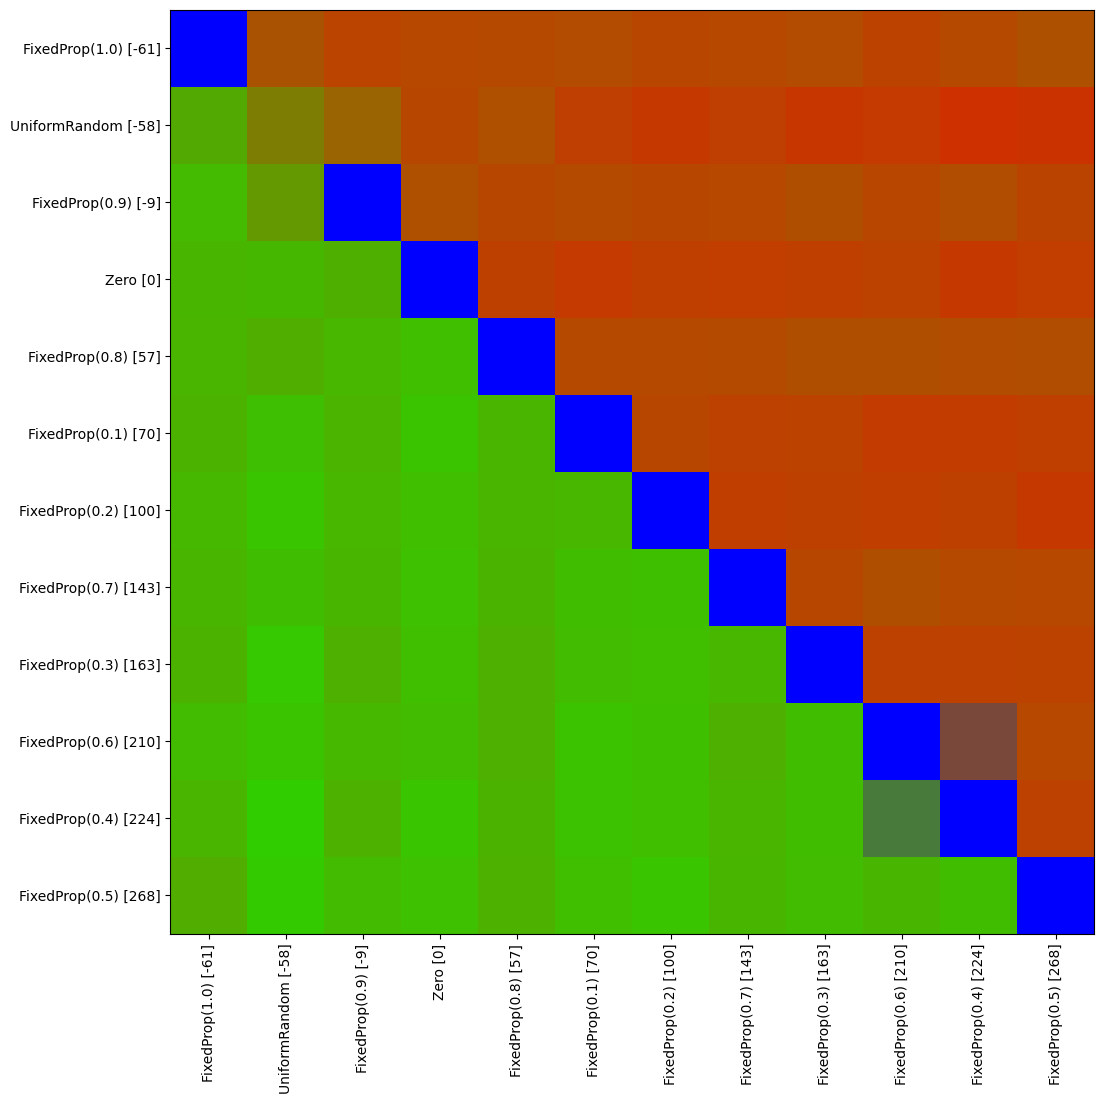

In [13]:
# Play an all-vs-all tournament with the strategies.
# Here we play 1000 games between each pair
game_results = game.play_tournament(strategy_list, 1000, rng)
# We can visualise the results as a playoff matrix, with approximate ELO scores
game.plot_game_results(strategy_list, game_results)

# The strategies are sorted by their inferred ELO score (with strategy_list[0] as the baseline of ELO zero)

# Each cell is coloured based on the number of games won by the row/column strategies
# Red represents wins by the column strategy
# Green represents wins by the row strategy
# Blue represents draws

In [14]:
# We can approximately rank the strategies with their inferred ELO scores
elo_scores = game.results_to_elo(game_results)
for i in np.argsort(elo_scores)[::-1]:
    print(f'{elo_scores[i]:>4.0f}  {str(strategy_list[i])}')

 268  FixedProp(0.5)
 224  FixedProp(0.4)
 210  FixedProp(0.6)
 163  FixedProp(0.3)
 143  FixedProp(0.7)
 100  FixedProp(0.2)
  70  FixedProp(0.1)
  57  FixedProp(0.8)
   0  Zero
  -9  FixedProp(0.9)
 -58  UniformRandom
 -61  FixedProp(1.0)


In [15]:
# We can look more closely at the results
row_wins, col_wins, draws = game_results

strategy_idx = 1
print(f'Results for strategy [{strategy_list[strategy_idx]}]:')
for opponent_idx, opponent in enumerate(strategy_list):
    num_wins = row_wins[strategy_idx, opponent_idx]
    num_losses = col_wins[strategy_idx, opponent_idx]
    num_draws = draws[strategy_idx, opponent_idx]
    print(f'  vs [{str(opponent).rjust(14)}]: {num_wins:> 6} wins, {num_losses:> 6} losses, {num_draws:> 6} draws')

Results for strategy [UniformRandom]:
  vs [          Zero]:    276 wins,    719 losses,      5 draws
  vs [ UniformRandom]:    987 wins,    987 losses,     26 draws
  vs [FixedProp(0.1)]:    246 wins,    750 losses,      4 draws
  vs [FixedProp(0.2)]:    226 wins,    773 losses,      1 draws
  vs [FixedProp(0.3)]:    213 wins,    787 losses,      0 draws
  vs [FixedProp(0.4)]:    192 wins,    808 losses,      0 draws
  vs [FixedProp(0.5)]:    201 wins,    796 losses,      3 draws
  vs [FixedProp(0.6)]:    230 wins,    769 losses,      1 draws
  vs [FixedProp(0.7)]:    249 wins,    747 losses,      4 draws
  vs [FixedProp(0.8)]:    316 wins,    683 losses,      1 draws
  vs [FixedProp(0.9)]:    395 wins,    601 losses,      4 draws
  vs [FixedProp(1.0)]:    666 wins,    323 losses,     11 draws


## The challenge: Learn a strategy with RL

Instead of hand-writing `MyStrategy`, we build a Gymnasium self-play environment and train a shared policy with JAX PPO.

The implementation lives in `higher_lower_rl.py`:
- `HigherLowerSelfPlayEnv` exposes the simultaneous two-player game as a Gymnasium environment.
- `train_self_play_ppo` runs a categorical PPO loop in JAX.
- `PPOPolicyStrategy` wraps the trained policy back into `game.Strategy` so it can be used by `game.play_game` and `game.play_tournament`.

The training reward is log-wealth growth plus a small terminal win bonus. Pure win/loss self-play is too symmetric here and gives a much weaker learning signal.


In [1]:
import matplotlib.pyplot as plt
import wandb
import deck

from higher_lower_rl import HigherLowerSelfPlayEnv, PPOPolicyStrategy, load_training_checkpoint, train_self_play_ppo

env = HigherLowerSelfPlayEnv(seed=0)
obs, info = env.reset()
print("Observation shape:", obs.shape)
print("Action space:", env.action_space)
print("First card:", deck.name_card(info["first_card"]))


Observation shape: (2, 60)
Action space: MultiDiscrete([81 81])
First card: Queen of Clubs (id=44)


In [2]:
import os

# Use WANDB_MODE=online after wandb.login() if you want live dashboard syncing.
wandb_mode = os.environ.get("WANDB_MODE", "online")

# Your training budget is measured in complete self-play games.
TOTAL_GAMES = 2_000_000
GAMES_PER_BATCH = 128
CHECKPOINT_PATH = "checkpoints/jax_ppo_self_play.pkl"
RESUME_FROM_CHECKPOINT = None
# Example: set RESUME_FROM_CHECKPOINT = CHECKPOINT_PATH and raise TOTAL_GAMES to continue training.

TRAINING_CONFIG = dict(
    seed=0,
    total_games=TOTAL_GAMES,
    episodes_per_batch=GAMES_PER_BATCH,
    ppo_epochs=4,
    minibatch_size=256,
    learning_rate=3e-4,
    entropy_coef=5e-3,
    use_wandb=True,
    wandb_project="higher-lower-v2-ppo",
    wandb_run_name="jax-ppo-self-play",
    wandb_mode=wandb_mode,
    checkpoint_path=CHECKPOINT_PATH,
    resume_from_checkpoint=RESUME_FROM_CHECKPOINT,
    checkpoint_every_games=2_000,
)

print("wandb mode:", wandb_mode)
print("training budget (games):", TOTAL_GAMES)
print("checkpoint:", CHECKPOINT_PATH)
trained_params, training_history = train_self_play_ppo(**TRAINING_CONFIG)
my_strategy = PPOPolicyStrategy(trained_params, name="MyStrategy(PPO)")


wandb mode: online
training budget (games): 2000000
checkpoint: checkpoints/jax_ppo_self_play.pkl


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/fracapuano/.netrc.
wandb: Currently logged in as: francescocapuano to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


/Users/fracapuano/Desktop/SQIF/.conda/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


agent_steps,▁▁▁▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███
games_played,▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇█████
rollout/mean_episode_length,█████████▇███████████████████████████▁██
rollout/mean_final_points,▁▂▁▄▃▄▄▄▅▄▄▆▆▅▅▅▅▆▆▃▅▆▄▅▅▅▄▆▇▃▅█▆▆▆▅▄▆▆▅
rollout/mean_match_result,▄▄▅▃▅▃▄▄▃▄▄▃▂▄▃▄▅▅▂▁▅▃▂▅▅▄▅▄▅▄▂▃▃█▃▃▅▇▃▄
train/entropy,▁▂▁▂▁▂▁▁▂▃▃▃▅▆▄▃▃▂▂▂▄▄▅▅▅▄▃▆▅▇▇█▆▅▄▆████
train/loss,▁▁▁▂▂▃▃▂▂▃▂▃▄▃▃▆▅▃▄▂▂▃▃▄▄▃▄▄▆▅▄▃█▆▄▄▄▃▃▃
train/policy_loss,▇█▇▆▅▄▄▅▅▆▄▂▆▅▅█▅▆▅▅▄▅▃▄▃▃▅▃▂▁▄▁▂▂▃▃▃▃▂▃
train/value_loss,▅▃▂▃▁▁▃▂▅▃▃▃▄▄▆▅▄▃▃▇▂▄▂▅█▆▃▅▆▄▇█▆▆▆▇▅▆▆▄
update,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇██
agent_steps,15993522


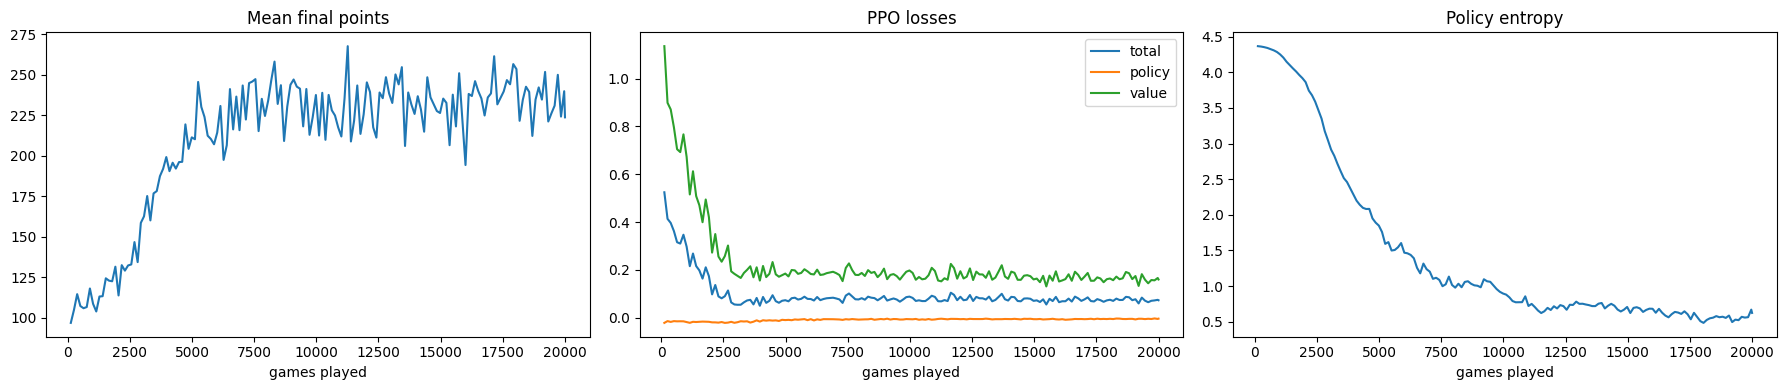

In [18]:
x_games = training_history["games_played"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(x_games, training_history["mean_final_points"])
axes[0].set_title("Mean final points")
axes[0].set_xlabel("games played")

axes[1].plot(x_games, training_history["loss"], label="total")
axes[1].plot(x_games, training_history["policy_loss"], label="policy")
axes[1].plot(x_games, training_history["value_loss"], label="value")
axes[1].set_title("PPO losses")
axes[1].set_xlabel("games played")
axes[1].legend()

axes[2].plot(x_games, training_history["entropy"])
axes[2].set_title("Policy entropy")
axes[2].set_xlabel("games played")

plt.tight_layout()
plt.show()


20260413 14:45:28 -- Played 478 tournaments (48%)
20260413 14:45:29 -- Played 955 tournaments (96%)


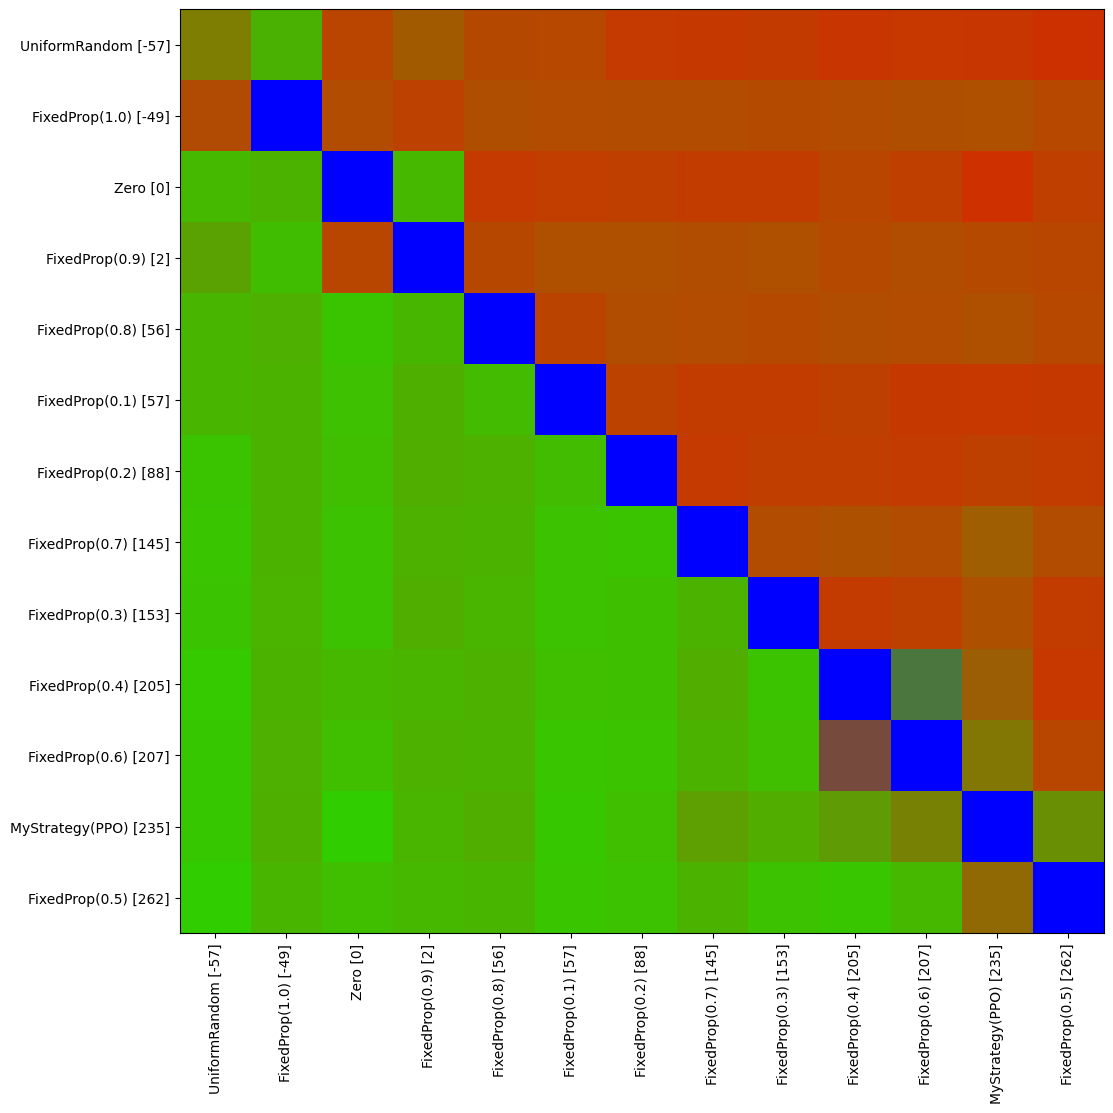

In [19]:
strategy_list: List[game.Strategy] = [
    ZeroStrategy(),
    UniformRandomStrategy(),
    *[FixedProportionStrategy((i + 1) / 10) for i in range(10)],
    my_strategy,
]

game_results = game.play_tournament(strategy_list, 1000, rng)
game.plot_game_results(strategy_list, game_results)

In [20]:
elo_scores = game.results_to_elo(game_results)
for i in np.argsort(elo_scores)[::-1]:
    print(f'{elo_scores[i]:>7.2f}  {str(strategy_list[i])}')

 262.47  FixedProp(0.5)
 235.41  MyStrategy(PPO)
 207.05  FixedProp(0.6)
 205.24  FixedProp(0.4)
 152.62  FixedProp(0.3)
 145.08  FixedProp(0.7)
  87.95  FixedProp(0.2)
  57.06  FixedProp(0.1)
  56.33  FixedProp(0.8)
   2.05  FixedProp(0.9)
   0.00  Zero
 -48.71  FixedProp(1.0)
 -57.31  UniformRandom
